<a href="https://colab.research.google.com/github/Harshitprajapati10/cv-lab-2026/blob/main/00_cub_200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision pytorch-lightning pandas scikit-learn pillow

In [ ]:
import os
import cv2
from google.colab.patches import cv2_imshow

# Download and set up
### Dataset: [Download dataset](https://data.caltech.edu/records/65de6-vp158)

In [ ]:
!find /content/drive/ -name "CUB_200_2011.tgz"

/content/drive/MyDrive/Z_data/CUB_200_2011.tgz


In [ ]:
DRIVE_FILE_PATH = "/content/drive/MyDrive/Z_data/CUB_200_2011.tgz"
!tar -xvzf "{DRIVE_FILE_PATH}" -C /content/

Streaming output truncated to the last 5000 lines.
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0050_111087.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0079_113288.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0004_111989.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0068_113247.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0127_111935.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0094_112773.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0028_113217.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0126_110959.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0007_111029.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0096_111519.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0120_113001.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0010_112678.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0025_111669.jpg
CUB_200_2011/images/118.House_Sparrow/House_Sparrow_0084_111300.j

In [ ]:
dataset_path = "/content/CUB_200_2011/images"
if os.path.exists(dataset_path):
    print(f"Success! Found {len(os.listdir(dataset_path))} species folders.")
else:
    print("Extraction failed. Please check the file path.")

Success! Found 200 species folders.


# Experiment on single image

In [ ]:
import cv2
img = cv2.imread("/content/CUB_200_2011/images/005.Crested_Auklet/Crested_Auklet_0070_785261.jpg")

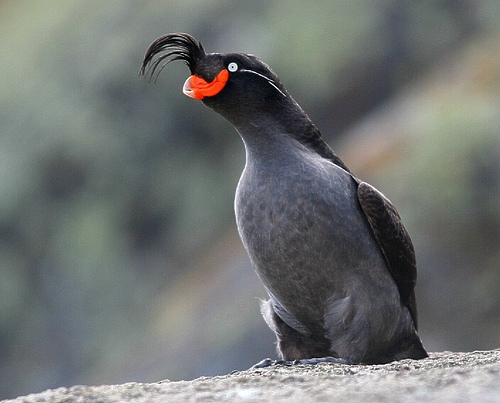

In [ ]:
cv2_imshow(img)

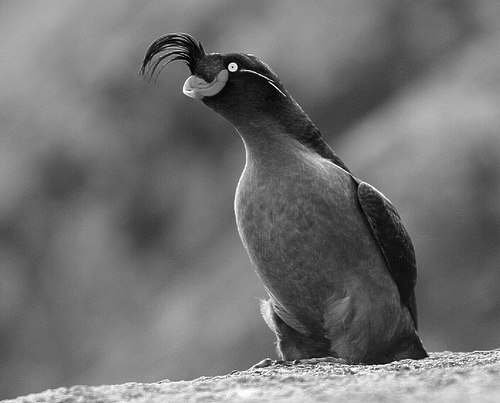

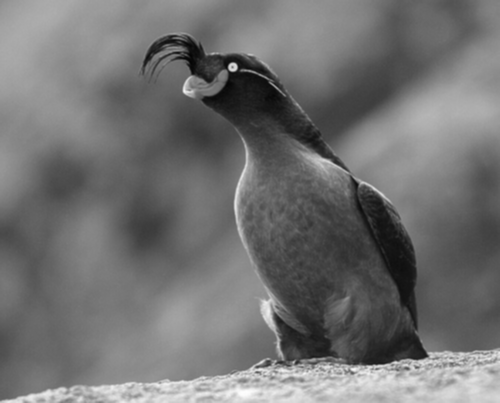

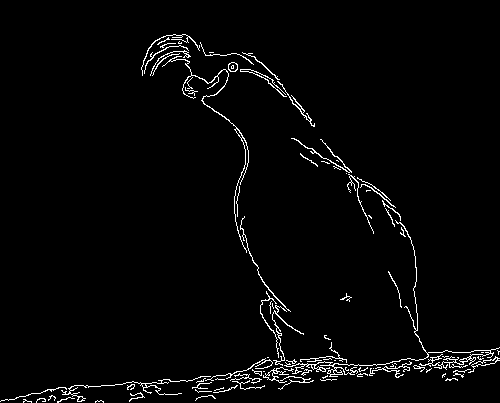

In [ ]:
# edge detection
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)
edges = cv2.Canny(image=img_blur, threshold1=100, threshold2=200)
cv2_imshow(img_gray)
cv2_imshow(img_blur)
cv2_imshow(edges)

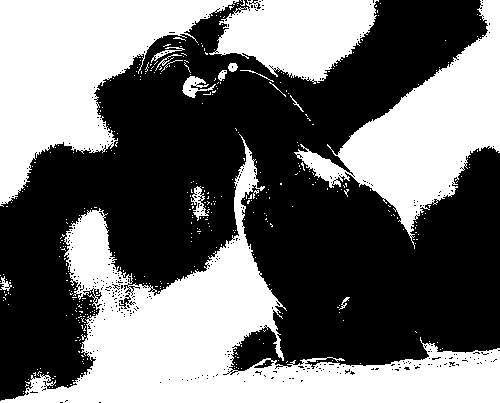

In [ ]:
# segmentation
ret, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2_imshow(thresh)

Gaussian Filtered Image (Blurred):


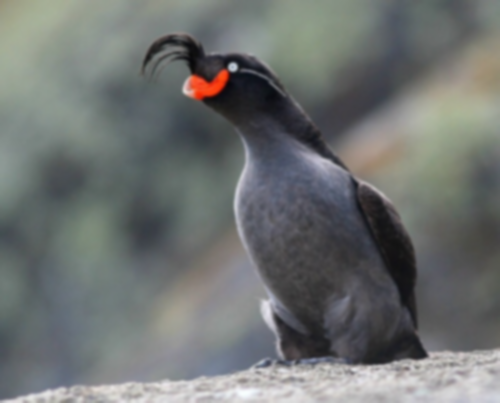

In [ ]:
img_filtered = cv2.GaussianBlur(img, (7, 7), 0)
print("Gaussian Filtered Image (Blurred):")
cv2_imshow(img_filtered)

Sobel Edge Detection:


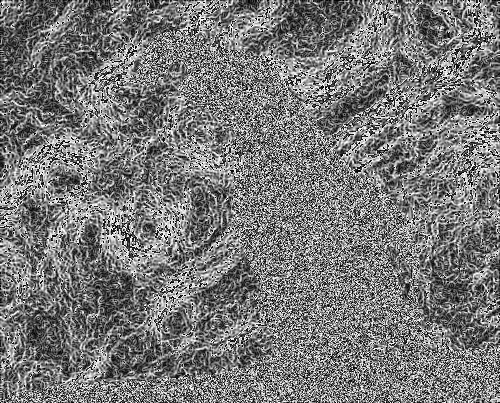

In [ ]:
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5) # Horizontal edges
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5) # Vertical edges
sobel_combined = cv2.magnitude(sobelx, sobely)
print("Sobel Edge Detection:")
cv2_imshow(sobel_combined.astype('uint8'))

Morphological Opening (Removes noise):


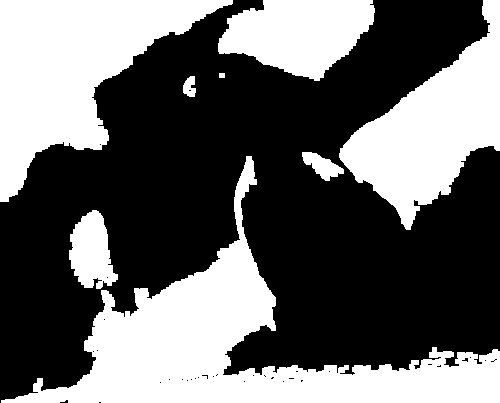

Morphological Closing (Fills holes):


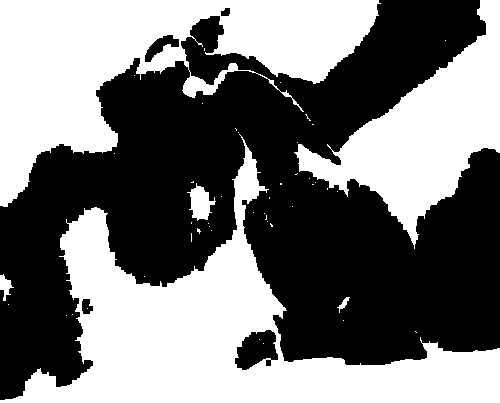

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# Opening: Erosion followed by Dilation (removes small noise objects)
img_opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Closing: Dilation followed by Erosion (fills small holes in foreground)
img_closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

print("Morphological Opening (Removes noise):")
cv2_imshow(img_opening)

print("Morphological Closing (Fills holes):")
cv2_imshow(img_closing)

# Segmentation

> Segmentation is the process of dividing an image into meaningful regions or objects so that pixels belonging to the same object or region are grouped together.

In computer vision, segmentation helps identify objects, boundaries, or regions in an image

#### We do four segmentation
1. Threshold Segmentation
2. K-Means Segmentation
3. Edge-based Segmentation (Canny)
4. Watershed Segmentation

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt

### 1. Threshold segmentation

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

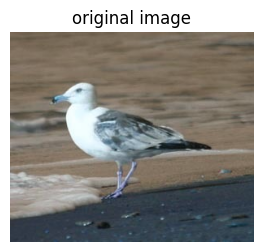

In [ ]:
test_img = cv2.imread("/content/CUB_200_2011/images/065.Slaty_backed_Gull/Slaty_Backed_Gull_0003_796032.jpg")
image_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img_gray = cv2.cvtColor(test_img,cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(12,6))
plt.subplot(231)
plt.imshow(test_img)
plt.title('original image')
plt.axis('off')

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

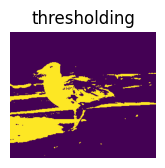

In [ ]:
_, thresh = cv2.threshold(test_img_gray, 127, 255, cv2.THRESH_BINARY)
plt.subplot(232)
plt.imshow(thresh)
plt.title('thresholding')
plt.axis('off')

### 2. k-means segmentation

(77700, 3)


(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

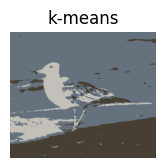

In [ ]:
pixel_values = image_rgb.reshape((-1,3))
pixel_values = np.float32(pixel_values)
print(pixel_values.shape)

k = 3
kmeans = KMeans(n_clusters=k)
labels = kmeans.fit_predict(pixel_values)

centers = np.uint8(kmeans.cluster_centers_)
segmented = centers[labels.flatten()]
segmented_image = segmented.reshape(image_rgb.shape)

plt.subplot(231)
plt.imshow(segmented_image)
plt.title('k-means')
plt.axis('off')

### 3. Edge detection

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

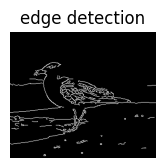

In [ ]:
edges = cv2.Canny(test_img_gray, 100, 200)
plt.subplot(233)
plt.imshow(edges, cmap='gray')
plt.title('edge detection')
plt.axis('off')


### 4. Watershed segmentation

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

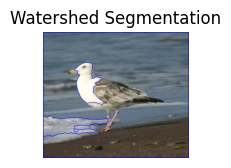

In [ ]:
img = test_img.copy()
gray_ws = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh_ws = cv2.threshold(gray_ws,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh_ws, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening,kernel,iterations=3)

dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
_, sure_fg = cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown==255] = 0

markers = cv2.watershed(img,markers)
img[markers == -1] = [255,0,0]

plt.subplot(235)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")


# Edge detection

> Edge detection is the process of identifying sharp intensity changes in an image. These intensity changes usually correspond to object boundaries.

Edges occur where the image gradient is large.

### Problems in Edge Detection

When applying edge detectors, two major issues appear:

#### 1. Poor Edge Localization

> The detected edge is not exactly at the object boundary.

#### 2. False Edges

> Edges appear due to noise or texture, not actual boundaries.

#### We will perform five types of edge detection
1. Roberts Edge Detection
2. Prewitt Edge Detection
3. Sobel Edge Detection
4. Laplacian Edge Detection
5. Canny Edge Detection

#### 1. Roberts

array([[100,  99,  99, ..., 106, 104, 101],
       [101, 101, 100, ..., 104, 102, 100],
       [103, 103, 102, ..., 102, 100,  97],
       ...,
       [ 60,  59,  59, ...,  68,  65,  63],
       [ 57,  58,  59, ...,  65,  63,  62],
       [ 57,  58,  60, ...,  69,  68,  68]], dtype=uint8)
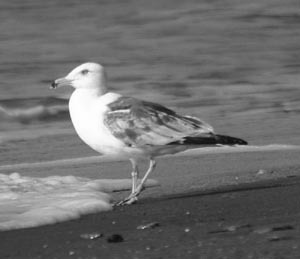

In [ ]:
test_img_gray

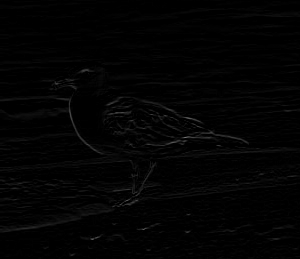

In [ ]:
roberts_cross_v = np.array([
    [1,0],
    [0,-1]
])
roberts_cross_h = np.array([
    [0,1],
    [-1,0]
])
roberts_cross_v = cv2.filter2D(test_img_gray, -1, roberts_cross_v)
roberts_cross_h = cv2.filter2D(test_img_gray, -1, roberts_cross_h)

roberts  = cv2.addWeighted(roberts_cross_v, 0.5, roberts_cross_h, 0.5, 0)

cv2_imshow(roberts)

#### 2. Prewitts

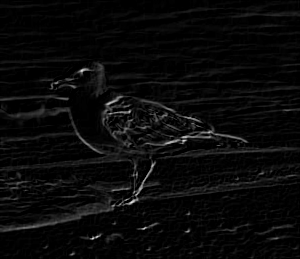

In [ ]:
kernelx = np.array([[1,0,-1],
                    [1,0,-1],
                    [1,0,-1]])

kernely = np.array([[1,1,1],
                    [0,0,0],
                    [-1,-1,-1]])

prewitt_x = cv2.filter2D(test_img_gray, -1, kernelx)
prewitt_y = cv2.filter2D(test_img_gray, -1, kernely)

prewitt = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

cv2_imshow(prewitt)

#### 3. Sobel

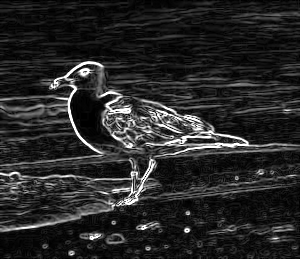

In [ ]:
sobelx = cv2.Sobel(test_img_gray, cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(test_img_gray, cv2.CV_64F,0,1,ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
cv2_imshow(sobel)

#### 4. laplacian

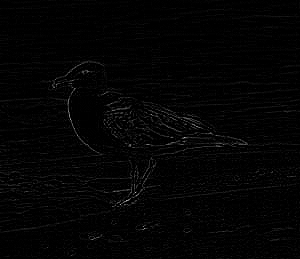

In [ ]:
laplacian = cv2.Laplacian(test_img_gray,cv2.CV_64F)
cv2_imshow(laplacian)

#### 5. Canny

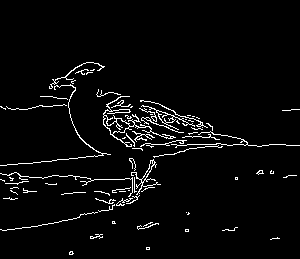

In [ ]:
canny = cv2.Canny(test_img_gray,100,200)
cv2_imshow(canny)

# VGG-16 FINE TUNING

In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torchvision.models as models
import pytorch_lightning as pl
import torchmetrics
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning import Trainer
from torch.utils.data import random_split


In [ ]:
class CUBDataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None):
        self.root = root_dir
        self.transform = transform

        images = pd.read_csv(os.path.join(root_dir,"images.txt"), sep=" ", names=["img_id","path"])
        labels = pd.read_csv(os.path.join(root_dir,"image_class_labels.txt"), sep=" ", names=["img_id","label"])
        split = pd.read_csv(os.path.join(root_dir,"train_test_split.txt"), sep=" ", names=["img_id","is_train"])

        data = images.merge(labels, on="img_id").merge(split, on="img_id")

        if train:
            data = data[data.is_train==1]
        else:
            data = data[data.is_train==0]

        self.data = data.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = os.path.join(self.root,"images",row.path)
        label = row.label - 1

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
class CUBDataModule(pl.LightningDataModule):

    def __init__(self, data_dir, batch_size=32):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],
                                 [0.229,0.224,0.225])
        ])

    def setup(self, stage=None):

        full_train = CUBDataset(self.data_dir, train=True, transform=self.transform)

        train_size = int(0.8 * len(full_train))
        val_size = len(full_train) - train_size

        self.train_dataset, self.val_dataset = random_split(
            full_train, [train_size, val_size]
        )

        self.test_dataset = CUBDataset(
            self.data_dir, train=False, transform=self.transform
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=32, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=32)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=32)

In [ ]:
class VGG16FineTune(pl.LightningModule):

    def __init__(self, num_classes=200, lr=1e-4):
        super().__init__()

        self.lr = lr

        self.model = models.vgg16(pretrained=True)

        # freeze early layers
        for param in self.model.features[:20].parameters():
            param.requires_grad = False

        # replace classifier
        self.model.classifier[6] = nn.Linear(4096, num_classes)

        self.loss = nn.CrossEntropyLoss()

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self,x):
        return self.model(x)

    def training_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x)

        loss = self.loss(logits,y)

        preds = torch.argmax(logits,dim=1)

        acc = self.train_acc(preds,y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):

      x, y = batch

      logits = self(x)

      loss = self.loss(logits, y)

      preds = torch.argmax(logits, dim=1)

      acc = self.val_acc(preds, y)

      self.log("val_loss", loss, prog_bar=True)
      self.log("val_acc", acc, prog_bar=True)

    def test_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x)

        loss = self.loss(logits,y)

        preds = torch.argmax(logits,dim=1)

        acc = self.test_acc(preds,y)

        self.log("test_loss",loss, prog_bar=True)
        self.log("test_acc",acc, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.1,
            patience=3
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": scheduler,
            "monitor": "val_loss"
        }

In [ ]:

data_dir = "CUB_200_2011"

data_module = CUBDataModule(data_dir, batch_size=32)

model = VGG16FineTune()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

checkpoint = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="best-vgg16-cub"
)

trainer = Trainer(
    max_epochs=50,
    accelerator="auto",
    callbacks=[early_stop, checkpoint],
    log_every_n_steps=10
)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifac

In [ ]:
trainer.fit(model, datamodule=data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VGG                │  135 M │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 129 M                                                                                            
Non-trainable params: 5.3 M                                                                                        
Total params: 135 M                                                                                                
Total estimated model params size (MB): 540                                                                        
Modules in train mode: 46                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

In [ ]:
!find -name best-vgg16-cub.ckpt

./lightning_logs/version_4/checkpoints/best-vgg16-cub.ckpt


In [ ]:
model = VGG16FineTune.load_from_checkpoint("./lightning_logs/version_4/checkpoints/best-vgg16-cub.ckpt")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model

VGG16FineTune(
  (model): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      

In [ ]:
trainer.test(model, datamodule=data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5973420739173889     │
│         test_loss         │    1.8157860040664673     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.8157860040664673, 'test_acc': 0.5973420739173889}]

# NN from scratch

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

In [19]:
X = torch.randn(3,4)
y = torch.randn(3,2)
input_size = 4
hidden_size = 5
output_size = 2

In [26]:
W1 = torch.randn(input_size, hidden_size, requires_grad=True)
W2 = torch.randn(hidden_size, output_size, requires_grad = True)
b1 = torch.randn(hidden_size, requires_grad = True)
b2 = torch.randn(output_size, requires_grad = True)

In [27]:
def forward(X):
    z1 = X @ W1 + b1
    a1 = F.relu(z1)
    z2 = a1 @ W2 + b2
    return z2

In [28]:
output = forward(X)

In [29]:
for epoch in range(500):
    output = forward(X)
    loss = F.mse_loss(output,y)
    loss.backward()

    with torch.no_grad():
        W1 -= 0.01 * W1.grad
        W2 -= 0.01 * W2.grad
        b1 -= 0.01 * b1.grad
        b2 -= 0.01 * b2.grad
        W1.grad.zero_()
        W2.grad.zero_()
        b1.grad.zero_()
        b2.grad.zero_()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 3.419153928756714
Epoch 100, Loss: 0.2904527187347412
Epoch 200, Loss: 0.11190899461507797
Epoch 300, Loss: 0.03870620205998421
Epoch 400, Loss: 0.014438326470553875


tensor([-0.4574, -0.6204], requires_grad=True)